# Теория информации и кодирования
## Основные понятия
Сегодня мы разберем на практике понятия, которые рассматривали на лекции: информация, сообщение, сигнал, количество информации, энтропия, дискретизация и квантование.

## Наши задачи на сегодня

* получить запись одного и того же звукового сигнала с разной частотой дискретизации и квантизацией.
* сравнить разборчивость голоса, и выбрать оптимальный вариант, когда голос еще разборчив, а сообщение занимает как можно меньше места

Начнем с подготовки: импорта необходимых нам библиотек

In [24]:
# установим необходимые пакеты
!pip install numpy scipy matplotlib pandas sounddevice soundfile requests

# импортируем нужные нам пакеты
import sys
import math
from pathlib import Path

import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display, Markdown

print(f"Версия Python: {sys.version.split()[0]}")
print(f"Текущая рабочая папка: {Path.cwd()}")

Версия Python: 3.8.1
Текущая рабочая папка: /home/aleksandr/Documents/Learning/2026-2027/1/InfromationAndCodingTheory


Мы начнем с работы со звуком. Давайте загрузим файл (да, он уже оцифрован, для получения файла выполнены дискретизация и квантование), но нам нужно что-то, с чем мы можем начать.

> Если вы запускаете этот блокнот локально, вы можете записать и использовать в дальнейшшем вашу собственную запись

Частота дискретизации: 44100 Гц
Тип данных: int16
Форма массива: (264641,)
Первые 10 отсчётов: [ 12   6 -10  -9   2   3   3   4   7   3]
10 отсчётов, начиная с 1 секунды: [143 121  99  79  71  61  24  -5 -10  -6]


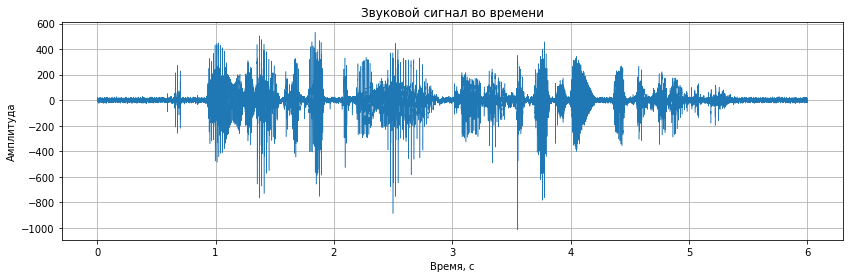

In [25]:
import io
import requests
from scipy.io import wavfile

from IPython.display import Audio, display
import matplotlib.pyplot as plt

record1_url = "https://alstutor.work/files/Record1.wav"

response1 = requests.get(record1_url, timeout=30)
response1.raise_for_status()

# response.content содержит файл как набор байтов.
# BytesIO позволяет работать с этими байтами как с файлом.
sample_rate1, audio1 = wavfile.read(io.BytesIO(response1.content))

# выделим один канал и будем дальше работать с ним
audio1 = audio1[:, 1]

print("Частота дискретизации:", sample_rate1, "Гц")
print("Тип данных:", audio1.dtype)
print("Форма массива:", audio1.shape)
print("Первые 10 отсчётов:", audio1[:10])
print("10 отсчётов, начиная с 1 секунды:", audio1[44100:44110])

display(Audio(audio1, rate=44100))

time = np.arange(len(audio1)) / sample_rate1

plt.figure(figsize=(14, 4))
plt.plot(time, audio1, linewidth=0.5)

plt.title("Звуковой сигнал во времени")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.grid(True)

plt.show()

> Самостоятельно

Пожалуйста, проделайте все то же самое для второй записи в ячейке ниже

In [26]:
# аналогичный анализ для второй записи
record2_url = "https://alstutor.work/files/Record2.wav"

> Самостоятельно:
Пожалуйста, рассчитайте и напишите в ячейке ниже:

* каков должен быть предполагаемый размер файла при заданных параметрах звука
* отличается ли реальный размер файла
* насколько
* как вы считаете, почему
* почему цифры в первых 10 отсчетах одинаковы и как это связано с графиком
* что вы можете сказать о записи тишины, как она отличается от записи голоса

Затем постройте график первой записи на интервале между 0.8 и 0.81 секунды.
Что вы можете сказать об этом графике?

Выводы:

In [27]:
# график записи на интервале между 0.8 и 0.81 секунды

Важным элементом является [спектрограмма сигнала](https://ru.wikipedia.org/wiki/Спектрограмма). Двайте построим спектрограмму нашего звука

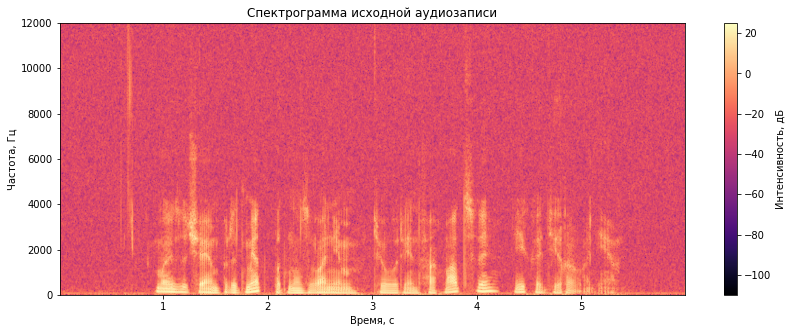

In [28]:
plt.figure(figsize=(14, 5))

plt.specgram(
    audio1,
    NFFT=1024,
    Fs=sample_rate1,
    noverlap=768,
    cmap="magma"
)

plt.title("Спектрограмма исходной аудиозаписи")
plt.xlabel("Время, с")
plt.ylabel("Частота, Гц")
plt.colorbar(label="Интенсивность, дБ")
plt.ylim(0, min(12_000, sample_rate1 / 2))
plt.show()

| Самостоятельно
* постройте спектрограмму для записанной тишины
* какие частоты присуствуют в записи голоса, какие - в записи тишины? Отличается ли их интенсивность?
* можно ли отличить запись тишины от записи голоса по спектрограмме? можно ли выделить моменты тишины на спектрограмме записи голоса?

In [29]:
# постройте спектрограммы

выводы по спектрограммам:


## Передискретизация и переквантование

Давайте попробуем преобразовать нашу запись, понизив (а затем и повысив тоже!) частоту дискретизации и количество уровней квантования.



In [30]:
old_rate = 44100
target_rates = [22_050, 11_025, 7_350, 4_410]  # все кратны 44100

resampled_versions = {}

for target_rate in target_rates:
    step = 44100 // target_rate  # деление нацело
    
    resampled = audio1[::step]
    resampled_versions[target_rate] = resampled

    print("Тип данных:", resampled.dtype)
    print("Форма массива:", resampled.shape)
    print("Первые 10 отсчётов:", resampled[:10])
    print("10 отсчётов, начиная с 1 секунды:", audio1[target_rate:target_rate + 10])

Тип данных: int16
Форма массива: (132321,)
Первые 10 отсчётов: [ 12 -10   2   3   7  -5  -3 -11  -1  11]
10 отсчётов, начиная с 1 секунды: [ 1 -3  2 -2  9 17  8 -1 -1 10]
Тип данных: int16
Форма массива: (66161,)
Первые 10 отсчётов: [12  2  7 -3 -1  8  2 19  0  2]
10 отсчётов, начиная с 1 секунды: [  2  -1   7   8   2   6   0 -10   5   1]
Тип данных: int16
Форма массива: (44107,)
Первые 10 отсчётов: [12  3 -3 11  2  2  2 -7  6  3]
10 отсчётов, начиная с 1 секунды: [ 9  0 -2  7  5 -1 -4 -5  4  5]
Тип данных: int16
Форма массива: (26465,)
Первые 10 отсчётов: [12 -5  8  2  0 -1  6  4  4  7]
10 отсчётов, начиная с 1 секунды: [-5 -7 -7  2  2  0 -3 -1  9 12]


Проиграйте все получившиеся записи и сравните с оригиналом в следующей ячейке, выберите минимально приемлимый вариант.

In [31]:
# проиграйте все получившиеся записи

Постройте спектрограммы всех вариантов и сравните их между собой. Что мы теряем, уменьшая частоту ддискретизации?

In [32]:
# постройте спетрограммы всех получившихся записей

Давайте проделаем то же самое с квантизацией. На данный момент у нас звук хранится в виде последовательности 16-битных чисел.

Допустим, один отсчет представлен в виде целого числа 0011 1011 1100 1110. Зная, что число записано в [позиционной системе счисления](https://ru.wikipedia.org/wiki/Позиционная_система_счисления), мы понимаем, что чем старше разряд, тем бОльший вклад он вносит в число (0001 - это единица, 0010 - это двойка, 0100 - это четверка, 1000 - это восьмерка).

Таким образом, для понижения разрядности числа достаточно заполнить соответствуюшие младшие разряды числа нулями (заодно это позволяет нам очень гибко подходить к квантизации, в том числе использовать 16-ти, 15-ти, 14-ти, и.т.д. битную квантизацию вместо 16-ти и 8-ми битной, если бы мы использовали только стандартные представления чисел, при этом в реальности все равно используя 16-ти разрядные числа).

Соответственно, для получения 15-ти битной квантизации, достаточно обнулить младший разряд. Для этого можно было бы использовать ьитовые операции, но есть способ проще - можно разделить число нацело на 2 и затем снова домножить на 2, то есть

In [33]:
num = 0b0110_0001_1100_1111
num = num // 2
num = num * 2
print(bin(num))

0b110000111001110


Поскольку мы используем NumPy, и звук представлен в виде массива NumPy, мы може просто разделить весь массив на 2 и домножить на 2, это равнносильно тому, кук если бы мы сделали то же самое с каждым элементом массива:

In [34]:
requant15 = (audio1 // 2) * 2

> Самостоятельно

Пожалуйста, выполните те же действия, что мы делали для передискретизации:
* постройте переквантизированные до 15, 14, 8, 6, и 4 бит записи 
* прослушайте их
* постройте спектрограммы
* выберите наиболее приемлимый вариант

In [35]:
# постройте разные передискретизации исходной записи
